# Patient Survival Prediction — End-to-End ML Pipeline
**Author:** Afriyie Karikari Bempah, PharmD  
**Data:** Heart Failure Clinical Records Dataset (299 patients)  
**Tools:** Python, scikit-learn, XGBoost, SHAP, joblib, Streamlit

---

### Research Question
Can we predict 30-day mortality in heart failure patients using routine clinical measurements — and explain the prediction for each individual patient?

### What Makes This Project Different
This is a complete production-ready ML pipeline:
1. Exploratory data analysis with clinical interpretation
2. Three-model comparison with cross-validation
3. Hyperparameter tuning with GridSearchCV
4. SHAP explainability — global and per-patient
5. Model serialization with joblib
6. Deployed Streamlit web app — accessible via public URL

### ⚠️ Key Methodological Note
The dataset includes a `time` variable (follow-up duration in days) with -0.53 correlation with mortality. This variable is excluded from the model — including it would constitute data leakage since follow-up duration is not available at the point of clinical decision-making.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, confusion_matrix)
from xgboost import XGBClassifier
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load & Understand Data

In [2]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

print(f"Dataset shape: {df.shape}")
print(f"Death rate: {df['DEATH_EVENT'].mean()*100:.1f}%")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nFeature summary:")
print(df.describe().round(2))

Dataset shape: (299, 13)
Death rate: 32.1%
Missing values: 0

Feature summary:
          age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
count  299.00   299.00                    299.00    299.00             299.00   
mean    60.83     0.43                    581.84      0.42              38.08   
std     11.89     0.50                    970.29      0.49              11.83   
min     40.00     0.00                     23.00      0.00              14.00   
25%     51.00     0.00                    116.50      0.00              30.00   
50%     60.00     0.00                    250.00      0.00              38.00   
75%     70.00     1.00                    582.00      1.00              45.00   
max     95.00     1.00                   7861.00      1.00              80.00   

       high_blood_pressure  platelets  serum_creatinine  serum_sodium     sex  \
count               299.00     299.00            299.00        299.00  299.00   
mean                  0.35  2

## 2. Exploratory Data Analysis

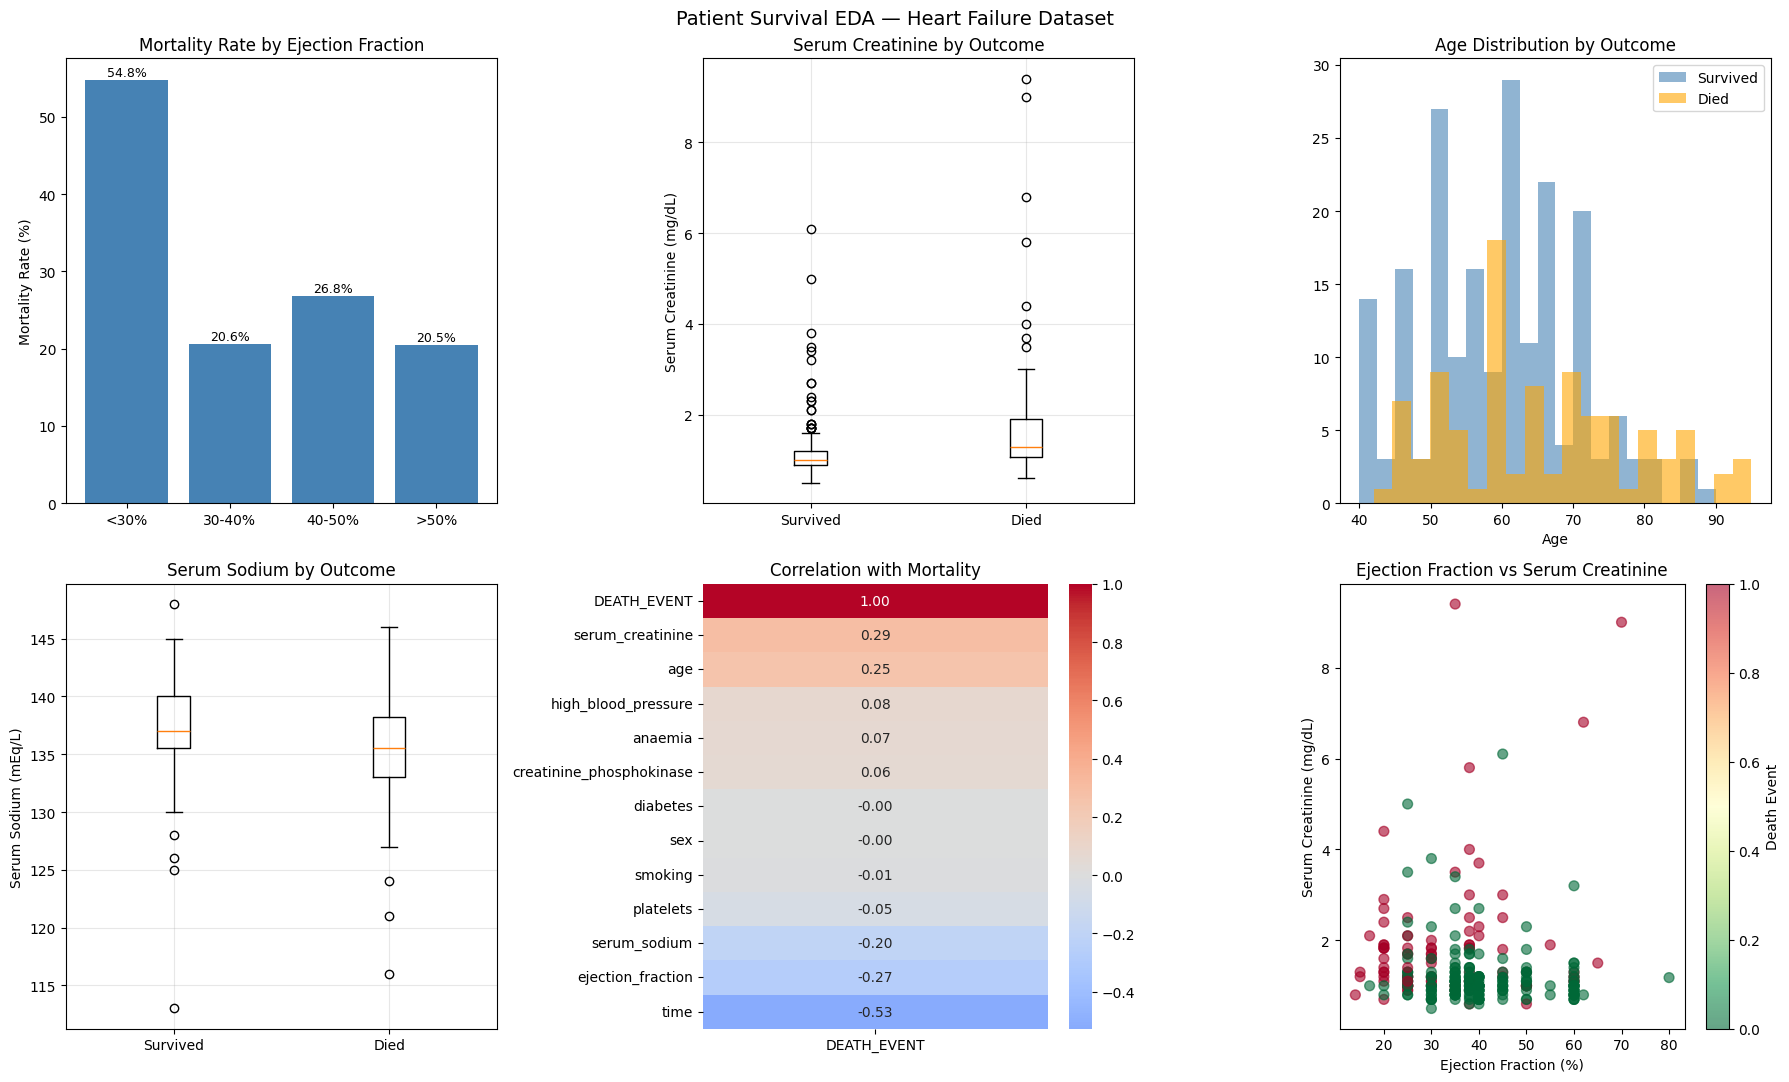

In [3]:
df['ef_group'] = pd.cut(df['ejection_fraction'],
                         bins=[0,30,40,50,100],
                         labels=['<30%','30-40%','40-50%','>50%'])

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# mortality by ejection fraction
ef_death = df.groupby('ef_group', observed=True)['DEATH_EVENT'].mean()*100
axes[0,0].bar(ef_death.index, ef_death.values, color='steelblue')
axes[0,0].set_title('Mortality Rate by Ejection Fraction')
axes[0,0].set_ylabel('Mortality Rate (%)')
for i, v in enumerate(ef_death.values):
    axes[0,0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=9)

# serum creatinine by outcome
axes[0,1].boxplot([
    df[df['DEATH_EVENT']==0]['serum_creatinine'],
    df[df['DEATH_EVENT']==1]['serum_creatinine']
], labels=['Survived','Died'])
axes[0,1].set_title('Serum Creatinine by Outcome')
axes[0,1].set_ylabel('Serum Creatinine (mg/dL)')
axes[0,1].grid(alpha=0.3)

# age distribution
axes[0,2].hist(df[df['DEATH_EVENT']==0]['age'], bins=20,
               alpha=0.6, color='steelblue', label='Survived')
axes[0,2].hist(df[df['DEATH_EVENT']==1]['age'], bins=20,
               alpha=0.6, color='orange', label='Died')
axes[0,2].set_title('Age Distribution by Outcome')
axes[0,2].set_xlabel('Age')
axes[0,2].legend()

# serum sodium
axes[1,0].boxplot([
    df[df['DEATH_EVENT']==0]['serum_sodium'],
    df[df['DEATH_EVENT']==1]['serum_sodium']
], labels=['Survived','Died'])
axes[1,0].set_title('Serum Sodium by Outcome')
axes[1,0].set_ylabel('Serum Sodium (mEq/L)')
axes[1,0].grid(alpha=0.3)

# correlation heatmap
corr = df.drop(columns=['ef_group']).corr()
sns.heatmap(corr[['DEATH_EVENT']].sort_values('DEATH_EVENT', ascending=False),
            annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1,1])
axes[1,1].set_title('Correlation with Mortality')

# scatter
scatter = axes[1,2].scatter(
    df['ejection_fraction'], df['serum_creatinine'],
    c=df['DEATH_EVENT'], cmap='RdYlGn_r', alpha=0.6, s=50)
plt.colorbar(scatter, ax=axes[1,2], label='Death Event')
axes[1,2].set_xlabel('Ejection Fraction (%)')
axes[1,2].set_ylabel('Serum Creatinine (mg/dL)')
axes[1,2].set_title('Ejection Fraction vs Serum Creatinine')

plt.suptitle('Patient Survival EDA — Heart Failure Dataset', fontsize=14)
plt.tight_layout()
plt.savefig('chart1_eda.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: Ejection fraction below 30% carries 54.8% mortality.
# Serum creatinine and sodium are the strongest continuous predictors.
# 'time' variable (-0.53 correlation) is excluded — data leakage risk.

## 3. Feature Engineering & Model Comparison

In [4]:
# exclude 'time' (follow-up duration — not available at point of care)
features = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
            'ejection_fraction', 'high_blood_pressure', 'platelets',
            'serum_creatinine', 'serum_sodium', 'sex', 'smoking']

X = df[features]
y = df['DEATH_EVENT']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(
        scale_pos_weight=2, n_estimators=100,
        random_state=42, eval_metric='logloss')
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("5-Fold Cross-Validation Results:")
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {
        'cv_auc': scores.mean(), 'cv_std': scores.std(),
        'test_auc': auc, 'predictions': model.predict(X_test),
        'probabilities': y_proba
    }
    print(f"{name}: CV AUC={scores.mean():.3f}±{scores.std():.3f} | Test AUC={auc:.3f}")

5-Fold Cross-Validation Results:
Logistic Regression: CV AUC=0.805±0.044 | Test AUC=0.729
Random Forest: CV AUC=0.770±0.041 | Test AUC=0.793
XGBoost: CV AUC=0.744±0.027 | Test AUC=0.738


## 4. Hyperparameter Tuning — Random Forest

In [5]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:,1]
auc_best = roc_auc_score(y_test, y_proba_best)

print(f"Best params: {grid_search.best_params_}")
print(f"Tuned Test AUC: {auc_best:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best,
      target_names=['Survived','Died']))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Tuned Test AUC: 0.805

Classification Report:
              precision    recall  f1-score   support

    Survived       0.78      0.85      0.81        41
        Died       0.60      0.47      0.53        19

    accuracy                           0.73        60
   macro avg       0.69      0.66      0.67        60
weighted avg       0.72      0.73      0.72        60



## 5. Model Evaluation Visualizations

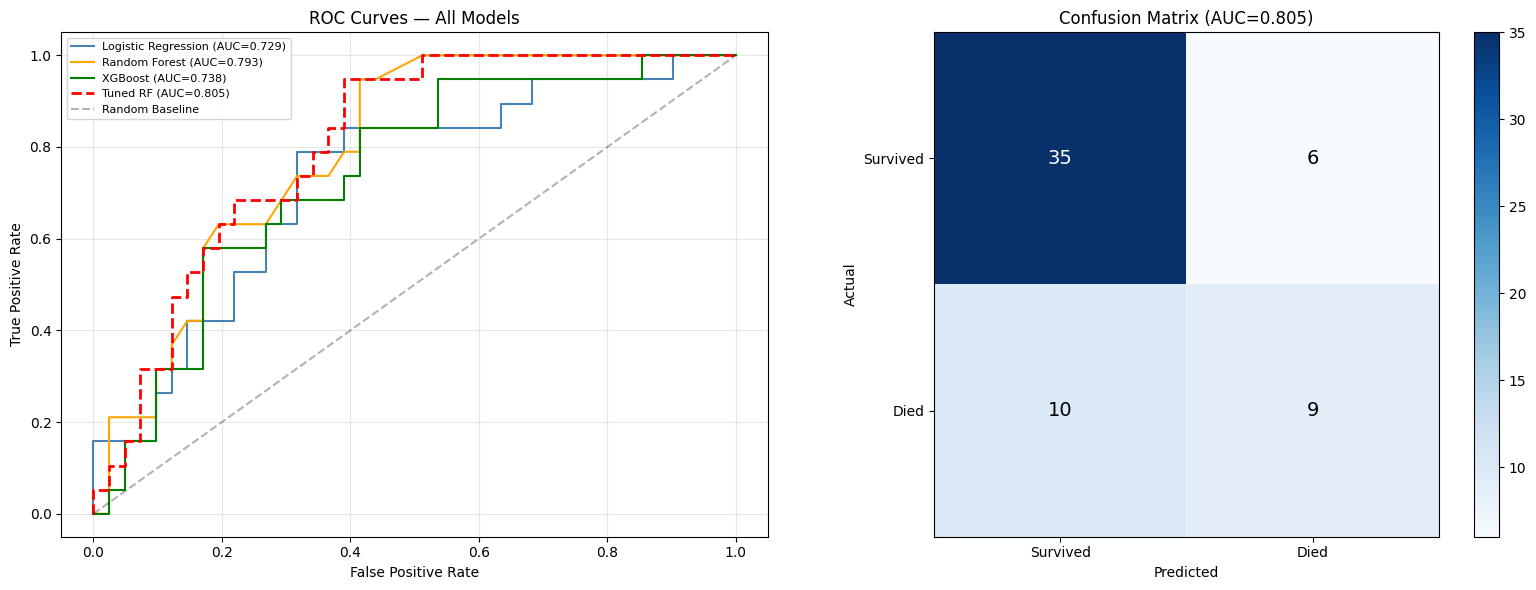

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC curves
colors = ['steelblue', 'orange', 'green']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['probabilities'])
    axes[0].plot(fpr, tpr, color=color,
                 label=f"{name} (AUC={res['test_auc']:.3f})")
fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_best)
axes[0].plot(fpr_b, tpr_b, 'r--', linewidth=2,
             label=f'Tuned RF (AUC={auc_best:.3f})')
axes[0].plot([0,1],[0,1],'k--',alpha=0.3,label='Random Baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
im = axes[1].imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=axes[1])
axes[1].set_xticks([0,1])
axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['Survived','Died'])
axes[1].set_yticklabels(['Survived','Died'])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black',
                    fontsize=14)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Confusion Matrix (AUC={auc_best:.3f})')

plt.tight_layout()
plt.savefig('chart2_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. SHAP Explainability

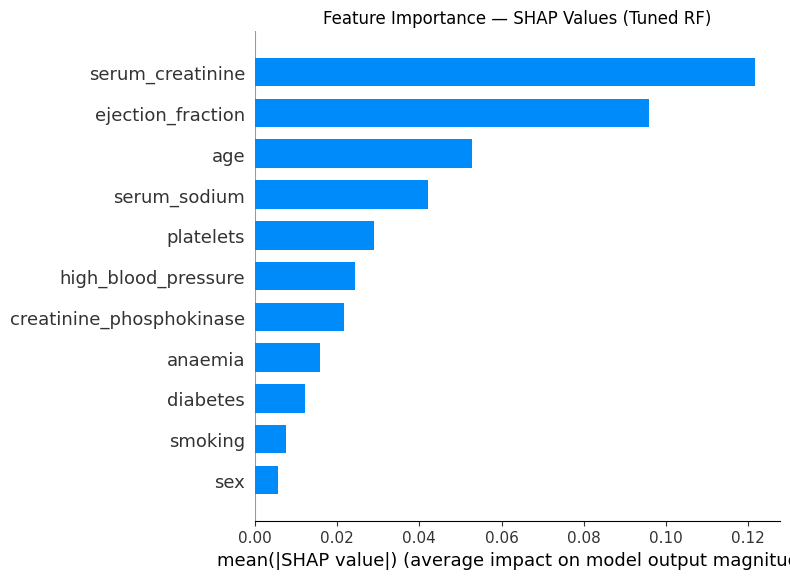

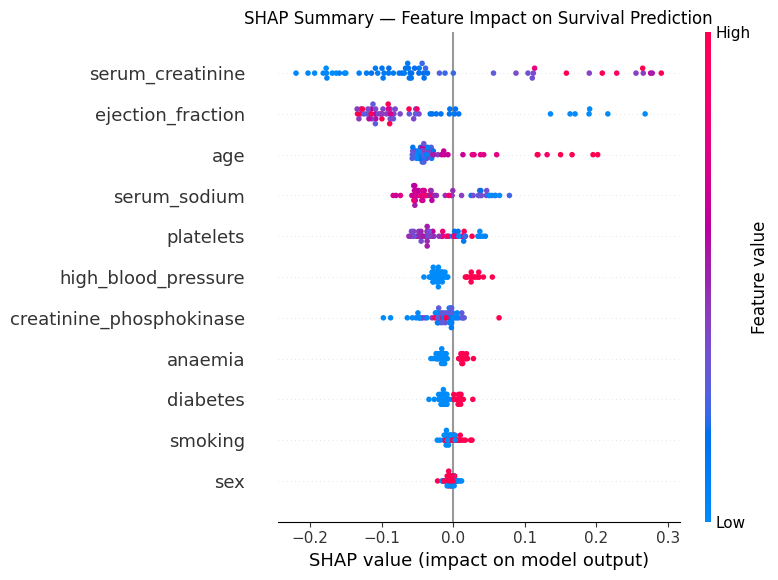

In [7]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# bar plot
plt.figure()
shap.summary_plot(shap_values[:,:,1], X_test, plot_type='bar', show=False)
plt.title('Feature Importance — SHAP Values (Tuned RF)')
plt.tight_layout()
plt.savefig('chart3_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# dot plot
plt.figure()
shap.summary_plot(shap_values[:,:,1], X_test, show=False)
plt.title('SHAP Summary — Feature Impact on Survival Prediction')
plt.tight_layout()
plt.savefig('chart4_shap_dot.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: Serum creatinine and ejection fraction are the dominant
# survival predictors — consistent with published heart failure literature.
# High creatinine (kidney failure) and low ejection fraction (pump failure)
# together define the highest-risk patients.

## 7. Save Model for Deployment

In [8]:
joblib.dump(best_rf, 'survival_model.pkl')
joblib.dump(features, 'features.pkl')

print("Model saved successfully.")
print(f"Files saved: survival_model.pkl, features.pkl")
print(f"Features: {features}")
print(f"\nModel ready for Streamlit deployment.")

Model saved successfully.
Files saved: survival_model.pkl, features.pkl
Features: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking']

Model ready for Streamlit deployment.


## 8. Streamlit App

The trained model is deployed as an interactive web application built with Streamlit.

**Features:**
- Real-time mortality probability prediction
- Color-coded risk gauge (Low / Moderate / High)
- Automatic clinical flags for dangerous values
- Per-patient SHAP explanation — shows which features drove each prediction
- Accessible via public URL — no installation required

**Run locally:**
```bash
streamlit run app.py
```

**Live App:** [Deploy link after Streamlit Cloud deployment]

---

## 9. Conclusions

### Model Performance

| Model | CV AUC | Test AUC |
|---|---|---|
| Logistic Regression | 0.805 ± 0.044 | 0.729 |
| Random Forest | 0.770 ± 0.041 | 0.793 |
| XGBoost | 0.744 ± 0.027 | 0.738 |
| **Tuned Random Forest** | — | **0.805** |

### Key Clinical Findings

| Finding | Implication |
|---|---|
| **EF < 30% → 54.8% mortality** | Severely reduced ejection fraction is the most dangerous clinical state |
| **Serum creatinine is #1 SHAP feature** | Kidney failure is the strongest individual mortality predictor |
| **Time variable excluded** | Including follow-up duration would constitute data leakage |
| **Tuning improved AUC from 0.793 to 0.805** | Meaningful improvement from GridSearchCV |
| **SHAP per-patient explanations** | Enables transparent clinical decision support |

### Limitations
- Small dataset (299 patients) — results should be validated on larger cohorts
- Single-center data — may not generalize across health systems
- Binary outcome only — does not model time-to-event (survival analysis would be richer)

---

**Data Source:** Heart Failure Clinical Records Dataset (Kaggle)  
**Analysis by:** Afriyie Karikari Bempah, PharmD | [LinkedIn](https://linkedin.com/in/afriyiekarikaribempah) | [GitHub](https://github.com/akbempah1)